# 02F: Regime-Filtered Meta-Signal

Combines the **T+1 short-horizon signal (02D)** and the **T+15 medium-term signal (02E)**
into a single, regime-aware trading signal that suppresses false breakouts.

## Updated integration idea (new vs old)
1. **New (recommended)**: T+1 side uses 02D full-universe cluster-news outputs (direct/cluster/macro composite).
2. **Legacy fallback**: if 02D artifacts are missing, T+1 falls back to price-only proxy.
3. **02F role unchanged**: regime filter + VIX conditioning + meta-learner still combine short/medium horizons.

## Why combine T+1 and T+15?

| Problem | Solution |
|---|---|
| T+1 is noisy on single-headline spikes | T+15 sees through single-day noise |
| T+15 reacts slowly to sudden regime changes | T+1 captures immediate response |
| High-VIX periods make short-term signals unreliable | VIX-conditional weighting shifts trust to T+15 |
| Sentiment velocity ↓ but short-term predicts ↑ | Velocity alignment filter discounts short-term signal |

## Three filtering mechanisms
1. **Regime Filter**: If T+15 disagrees with short-term direction, discount short-term confidence
2. **Sentiment Velocity Alignment**: Rising narrative momentum must align with short-term direction
3. **VIX-Conditional Weighting**: High VIX → trust T+15 more; low VIX → trust T+1 more

## Output files
- `02F_meta_signal_predictions.csv` — combined daily signal with weights
- `02F_backtest_performance.csv` — Sharpe / drawdown for all strategy variants


In [25]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost yfinance scipy



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# ── Config ─────────────────────────────────────────────────────────
FAST_MODE      = False
FAST_STOCKS    = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
VIX_HIGH_THRESH = 25.0   # above this VIX, shift weight toward T+15
VIX_MED_THRESH  = 18.0   # below this VIX, shift weight toward T+1

# 02D short-term signal blending
USE_02D_CLUSTERNEWS_COMPOSITE = True
W_PRICE_T1 = 0.70
W_NEWS_T1  = 0.30

print('[OK] Config loaded')
print(f'FAST_MODE={FAST_MODE} | USE_02D_CLUSTERNEWS_COMPOSITE={USE_02D_CLUSTERNEWS_COMPOSITE}')

[OK] Config loaded
FAST_MODE=False | USE_02D_CLUSTERNEWS_COMPOSITE=True


In [27]:
# ── Path resolution ──────────────────────────────────────────────
cwd = Path.cwd()
if cwd.name == 'implementation' and cwd.parent.name == '02_stock_price_regression':
    reg_root = cwd.parent
elif cwd.name == '02_stock_price_regression':
    reg_root = cwd
elif (cwd / 'project_folder' / '02_stock_price_regression').exists():
    reg_root = cwd / 'project_folder' / '02_stock_price_regression'
else:
    reg_root = cwd

workspace_root = reg_root.parent
data_dir  = reg_root / 'data'
graph_dir = reg_root / 'graph'
data_dir.mkdir(parents=True, exist_ok=True)
graph_dir.mkdir(parents=True, exist_ok=True)
print(f'Data dir : {data_dir}')


Data dir : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data


In [28]:
# ══════════════════════════════════════════════════════════════════
# Load T+1 signal source from 02D (new full-universe cluster-news aware)
# ══════════════════════════════════════════════════════════════════

d02d_news_path    = data_dir / '02D_cluster_news_features.csv'
d02d_xgb_path     = data_dir / '02D_xgb_baseline_vs_clusternews.csv'

cluster_data_dir  = workspace_root / '03_stock_clustering_analysis' / 'data'
price_candidates  = [
    cluster_data_dir / 'sp500_raw.csv',
    data_dir / 'sp500_raw.csv',
    data_dir / '02C_sp500_raw.csv',
]
price_path = next((p for p in price_candidates if p.exists()), None)

if price_path is None:
    raise FileNotFoundError(
        'Cannot find sp500_raw.csv. Please run 02C or 02D first.')

raw = pd.read_csv(price_path)
raw.columns = [c.strip() for c in raw.columns]
if 'name' in raw.columns and 'Name' not in raw.columns:
    raw.rename(columns={'name': 'Name'}, inplace=True)
close_col = next((c for c in raw.columns if c.lower() == 'close'), 'close')
if close_col != 'Close':
    raw.rename(columns={close_col: 'Close'}, inplace=True)
raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
raw = raw.dropna(subset=['Name', 'date']).sort_values(['Name', 'date']).reset_index(drop=True)

if FAST_MODE:
    raw = raw[raw['Name'].isin(FAST_STOCKS)].copy()

raw['ret_1d'] = raw.groupby('Name')['Close'].pct_change(1)
raw['log_ret_1d'] = np.log(raw['Close'] / raw.groupby('Name')['Close'].shift(1))

# ── Load 02D cluster-news features and build short-term sentiment composite ─
if d02d_news_path.exists() and USE_02D_CLUSTERNEWS_COMPOSITE:
    news_feat = pd.read_csv(d02d_news_path)
    news_feat['date'] = pd.to_datetime(news_feat['date'], errors='coerce').dt.normalize()
    news_feat['Name'] = news_feat['Name'].astype(str).str.strip()

    needed_cols = ['direct_sentiment_10d', 'cluster_sentiment_10d', 'macro_sentiment_10d']
    if all(c in news_feat.columns for c in needed_cols):
        news_feat['sent_02d'] = (
            0.50 * news_feat['direct_sentiment_10d'].fillna(0.0)
            + 0.35 * news_feat['cluster_sentiment_10d'].fillna(0.0)
            + 0.15 * news_feat['macro_sentiment_10d'].fillna(0.0)
        )
        if 'news_intensity_10d' in news_feat.columns:
            news_feat['sent_02d'] = news_feat['sent_02d'] * (1.0 + 0.10 * news_feat['news_intensity_10d'].fillna(0.0))
        raw = raw.merge(news_feat[['Name', 'date', 'sent_02d']], on=['Name', 'date'], how='left')
        raw['sent_02d'] = raw['sent_02d'].fillna(0.0)
        print('[OK] 02D composite sentiment loaded (direct/cluster/macro).')
    else:
        raw['sent_02d'] = 0.0
        print('[WARN] 02D feature columns incomplete. Fallback sentiment = 0.')
else:
    raw['sent_02d'] = 0.0
    print('[WARN] 02D cluster-news file missing or disabled. Fallback sentiment = 0.')

# ── Load 02E multi-horizon predictions ───────────────────────────
e_pred_path = data_dir / '02E_multi_horizon_predictions.csv'
e_feat_path = data_dir / '02E_trend_features.csv'

if e_pred_path.exists():
    e_preds = pd.read_csv(e_pred_path)
    e_preds['date'] = pd.to_datetime(e_preds['date'], errors='coerce').dt.normalize()
    e_preds['Name'] = e_preds['Name'].astype(str).str.strip()
    print(f'[OK] 02E predictions loaded: {len(e_preds):,} rows')
    print('Columns:', e_preds.columns.tolist())
else:
    print('[WARN] 02E predictions not found — creating synthetic signal for demonstration')
    e_preds = raw[['Name', 'date']].copy()
    e_preds['pred_T5']  = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(5, min_periods=2).mean().shift(1)).values
    e_preds['pred_T10'] = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(10, min_periods=3).mean().shift(1)).values
    e_preds['pred_T15'] = raw.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(15, min_periods=5).mean().shift(1)).values
    e_preds['true_T5']  = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-5)) / raw['Close'])
    e_preds['true_T10'] = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-10)) / raw['Close'])
    e_preds['true_T15'] = np.log(
        raw.groupby('Name')['Close'].transform(lambda x: x.shift(-15)) / raw['Close'])

print(f'Price rows: {len(raw):,}')
print(raw[['Name','date','Close','ret_1d','sent_02d']].head(3))

[OK] 02D composite sentiment loaded (direct/cluster/macro).
[OK] 02E predictions loaded: 117,588 rows
Columns: ['Name', 'date', 'cluster', 'pred_T5', 'true_T5', 'pred_T10', 'true_T10', 'pred_T15', 'true_T15']
Price rows: 619,040
  Name       date     Close    ret_1d  sent_02d
0    A 2013-02-08 45.080000       NaN  0.000000
1    A 2013-02-11 44.600000 -0.010648  0.000000
2    A 2013-02-12 44.620000  0.000448  0.000000


In [29]:
# ══════════════════════════════════════════════════════════════════
# Build merged signal DataFrame
# ══════════════════════════════════════════════════════════════════

# T+1 component now blends price short-term momentum and 02D news composite.
# T+15 component still comes from 02E multi-horizon forecasting.


# Price-side short-term proxy
raw['t1_price_proxy'] = raw.groupby('Name')['log_ret_1d'].transform(
    lambda x: x.ewm(span=5, adjust=False).mean().shift(1)
)

# News-side short-term proxy (already aligned by date)
raw['t1_news_proxy'] = raw.groupby('Name')['sent_02d'].transform(lambda x: x.shift(1)).fillna(0.0)

# Final T+1 proxy
raw['t1_proxy'] = W_PRICE_T1 * raw['t1_price_proxy'].fillna(0.0) + W_NEWS_T1 * raw['t1_news_proxy'].fillna(0.0)

sig_df = raw[['Name', 'date', 'log_ret_1d', 't1_proxy', 'sent_02d']].copy()
sig_df = sig_df.merge(
    e_preds[['Name', 'date', 'pred_T15', 'true_T15']].copy(),
    on=['Name', 'date'], how='inner'
)

# ── Load sentiment velocity from 02E trend features if available ─
if e_feat_path.exists():
    e_feat = pd.read_csv(e_feat_path)
    e_feat['date'] = pd.to_datetime(e_feat['date'], errors='coerce').dt.normalize()
    if 'sentiment_velocity_10d' in e_feat.columns:
        sig_df = sig_df.merge(
            e_feat[['Name', 'date', 'sentiment_velocity_10d']],
            on=['Name', 'date'], how='left'
        )
        sig_df['sentiment_velocity_10d'] = sig_df['sentiment_velocity_10d'].fillna(0.0)
    else:
        sig_df['sentiment_velocity_10d'] = 0.0
else:
    sig_df['sentiment_velocity_10d'] = 0.0

sig_df = sig_df.dropna(subset=['log_ret_1d', 't1_proxy', 'pred_T15'])
sig_df = sig_df.sort_values(['Name', 'date']).reset_index(drop=True)

print(f'Signal DataFrame: {len(sig_df):,} rows')
print(sig_df.head(3).to_string())

Signal DataFrame: 117,583 rows
  Name       date  log_ret_1d  t1_proxy  sent_02d  pred_T15  true_T15  sentiment_velocity_10d
0    A 2017-02-13    0.003172  0.002591  0.000000  0.001065  0.013566                0.000000
1    A 2017-02-14   -0.002577  0.002467  0.000000 -0.000701  0.020040                0.000000
2    A 2017-02-15    0.024116  0.001044  0.000000 -0.005296 -0.003688                0.000000


In [30]:
# ══════════════════════════════════════════════════════════════════
# VIX-Conditional Weighting
# ══════════════════════════════════════════════════════════════════
# Attempt to fetch real VIX data via yfinance; fall back to implied
# volatility proxy (cross-sectional average realized vol).

import yfinance as yf

try:
    vix_raw = yf.download('^VIX',
                          start=sig_df['date'].min().strftime('%Y-%m-%d'),
                          end=(sig_df['date'].max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
                          progress=False)
    vix_raw = vix_raw[['Close']].rename(columns={'Close': 'VIX'}).reset_index()
    vix_raw.columns = ['date', 'VIX']
    vix_raw['date'] = pd.to_datetime(vix_raw['date']).dt.normalize()
    # Handle MultiIndex columns from yfinance
    if isinstance(vix_raw.columns, pd.MultiIndex):
        vix_raw.columns = vix_raw.columns.get_level_values(0)
    vix_raw = vix_raw.dropna()
    print(f'[OK] VIX data fetched: {len(vix_raw):,} rows')
    vix_available = len(vix_raw) > 0
except Exception as e:
    print(f'[WARN] VIX fetch failed ({e}) — using realized vol proxy')
    vix_available = False

if not vix_available:
    # Proxy: 20-day rolling cross-sectional average of individual stock volatilities
    vix_proxy = (
        sig_df.groupby('date')['log_ret_1d']
        .std().reset_index()
        .rename(columns={'log_ret_1d': 'daily_xsec_vol'})
        .sort_values('date')
    )
    vix_proxy['VIX'] = (
        vix_proxy['daily_xsec_vol'].rolling(20, min_periods=5).mean() * np.sqrt(252) * 100
    )
    vix_raw = vix_proxy[['date', 'VIX']].dropna()
    print(f'[OK] VIX proxy computed: {len(vix_raw):,} rows')

# Merge VIX into signal DataFrame
sig_df = sig_df.merge(vix_raw, on='date', how='left')
sig_df['VIX'] = sig_df.groupby('Name')['VIX'].transform(
    lambda x: x.fillna(method='ffill').fillna(x.median()))

# VIX regime classification
sig_df['vix_regime'] = pd.cut(
    sig_df['VIX'],
    bins=[-np.inf, VIX_MED_THRESH, VIX_HIGH_THRESH, np.inf],
    labels=['Low', 'Medium', 'High']
)
print(sig_df['vix_regime'].value_counts().to_string())


[OK] VIX data fetched: 234 rows
vix_regime
Low       117583
Medium         0
High           0


In [31]:
# ══════════════════════════════════════════════════════════════════
# Meta-Signal Construction — Three Filters (CORRECTED)
# ══════════════════════════════════════════════════════════════════
#
# DESIGN FIX: T+15 log-return prediction is NOT additive to the T+1 signal.
# A T+15 prediction tells us the *medium-term direction* (trend regime),
# not the T+1 magnitude. We use it as a direction multiplier / discount factor:
#   - T+15 agrees with T+1 direction → boost T+1 confidence (× 1.2)
#   - T+15 disagrees with T+1 direction → discount T+1 signal (× discount_factor)
#   - VIX-conditional: high VIX → heavier discount on disagreement
#
# This avoids the "T+15 positive but T+1 negative" sign-flip problem
# that caused the rule-based meta to show Sharpe = -3.72 in the raw version.

def compute_meta_signal(df,
                        vix_high=VIX_HIGH_THRESH,
                        vix_med=VIX_MED_THRESH):
    """
    Compute the 02F meta-signal combining T+1 (02D proxy) and T+15 (02E).

    Key design change: T+15 is used as a DIRECTION CONFIDENCE MODIFIER,
    not an additive score. If T+15 agrees with T+1 direction, confidence
    increases; if it disagrees, confidence decreases proportionally to
    T+15 magnitude and VIX stress level.

    Returns a copy of df with new columns:
        w_t1           : base weight on T+1 signal  (0-1, VIX-conditional)
        w_t15          : base weight on T+15 signal (0-1, VIX-conditional)
        t15_align      : 1 if T+15 agrees with T+1 direction, else 0
        regime_filter  : confidence multiplier [0.2, 1.2]
        vel_align      : 1.0 or 0.75 based on sentiment velocity alignment
        meta_score     : confidence-adjusted T+1 signal score
        meta_signal    : final position {+1, -1}
    """
    df = df.copy()

    # ── 1) VIX-Conditional base weight ────────────────────────────
    w_t1 = np.where(
        df['VIX'] > vix_high, 0.30,
        np.where(df['VIX'] < vix_med, 0.70, 0.50)
    )
    w_t15 = 1.0 - w_t1
    df['w_t1']  = w_t1
    df['w_t15'] = w_t15

    # ── 2) Direction alignment (CORRECTED) ────────────────────────
    # T+15 direction must agree with T+1 direction — if not, discount T+1
    t1_dir  = np.sign(df['t1_proxy'])
    t15_dir = np.sign(df['pred_T15'])
    t15_align = (t1_dir == t15_dir).astype(float)  # 1 = agree, 0 = disagree
    df['t15_align'] = t15_align

    # Rolling realized vol per stock (used to scale the discount)
    # Use expanding std as causal fallback for early rows where the 20-day window
    # is not yet full. This avoids using the full-series std() which includes
    # test-period returns.
    df['real_vol'] = df.groupby('Name')['log_ret_1d'].transform(
        lambda x: x.rolling(20, min_periods=5).std()
                   .fillna(x.expanding(min_periods=1).std()))

    # Confidence modifier:
    #   aligned  → multiply by 1.0 + w_t15 * |T+15_pred| / real_vol * scale_factor
    #   disagreed → multiply by 1.0 - w_t15 * |T+15_pred| / real_vol * scale_factor
    # Cap the modifier between [0.20, 1.20] to avoid extreme suppression/amplification
    scale = 2.0
    t15_magnitude = df['pred_T15'].abs() / (df['real_vol'] + 1e-8)  # normalised
    direction_boost = np.where(
        t15_align == 1,
        1.0 + df['w_t15'] * t15_magnitude.clip(0, 0.5) * scale,
        1.0 - df['w_t15'] * t15_magnitude.clip(0, 0.5) * scale
    )
    df['regime_filter'] = np.clip(direction_boost, 0.20, 1.20)

    # ── 3) Sentiment velocity alignment ──────────────────────────
    vel_sign  = np.sign(df['sentiment_velocity_10d'].replace(0, np.nan).fillna(0))
    vel_align = np.where(
        vel_sign == 0, 1.0,
        np.where(vel_sign == t1_dir, 1.0, 0.75)
    )
    df['vel_align'] = vel_align

    # ── Combined meta-score (CORRECTED) ──────────────────────────
    # Base: T+1 signal (carry proxy), adjusted by regime confidence
    df['meta_score'] = (
        df['t1_proxy']           # T+1 direction and magnitude
        * df['regime_filter']    # amplified/discounted by T+15 agreement
        * df['vel_align']        # further discounted if sentiment velocity disagrees
    )

    # ── Final position ─────────────────────────────────────────────
    df['meta_signal'] = np.sign(df['meta_score'])

    return df


sig_df = compute_meta_signal(sig_df)

# Also compute pure T+1 and T+15 signals as baselines
sig_df['signal_t1']  = np.sign(sig_df['t1_proxy'])
sig_df['signal_t15'] = np.sign(sig_df['pred_T15'])

print('Meta-signal computed (corrected design).')
print('Direction alignment rate:', sig_df['t15_align'].mean().round(3))
print('Regime filter stats:')
print(sig_df['regime_filter'].describe().round(3))
print()
print(sig_df[['Name', 'date', 'VIX', 'w_t1', 't15_align', 'regime_filter',
              'vel_align', 'meta_score', 'meta_signal']].head(8).to_string())


Meta-signal computed (corrected design).
Direction alignment rate: 0.452
Regime filter stats:
count   117078.000000
mean         0.946000
std          0.214000
min          0.700000
25%          0.700000
50%          0.944000
75%          1.200000
max          1.200000
Name: regime_filter, dtype: float64

  Name       date       VIX     w_t1  t15_align  regime_filter  vel_align  meta_score  meta_signal
0    A 2017-02-13 11.070000 0.700000   1.000000            NaN   1.000000         NaN          NaN
1    A 2017-02-14 10.740000 0.700000   0.000000       0.896505   1.000000    0.002212     1.000000
2    A 2017-02-15 11.970000 0.700000   0.000000       0.773829   1.000000    0.000808     1.000000
3    A 2017-02-16 11.760000 0.700000   1.000000       1.141927   1.000000    0.007220     1.000000
4    A 2017-02-17 11.490000 0.700000   0.000000       0.941919   1.000000    0.000624     1.000000
5    A 2017-02-21 11.570000 0.700000   1.000000       1.100376   1.000000    0.004445     1.000000


In [32]:
# ══════════════════════════════════════════════════════════════════
# Optional: Trained Meta-Learner (Ridge Regression)
# Learns optimal weights from data instead of fixed VIX thresholds
# ══════════════════════════════════════════════════════════════════

# Build meta-features for the learned meta-learner
meta_feat_cols = [
    't1_proxy',          # T+1 signal
    'pred_T15',          # T+15 signal
    'VIX',               # market stress level
    'sentiment_velocity_10d',  # narrative momentum
    'real_vol',          # realized vol (already computed)
]
sig_df['t1_t15_disagree'] = np.abs(
    np.sign(sig_df['t1_proxy']) - np.sign(sig_df['pred_T15']))  # 0 or 2
# Signal disagreement under stress
sig_df['stress_disagree'] = sig_df['VIX'] * sig_df['t1_t15_disagree']
meta_feat_cols += ['t1_t15_disagree', 'stress_disagree']

# Temporal split for meta-learner (same 80/20 logic)
all_dates = sig_df['date'].sort_values().unique()
split_date = pd.Timestamp(np.quantile(
    all_dates.astype(np.int64), 0.80, interpolation='nearest'))

meta_train = sig_df[sig_df['date'] <= split_date].dropna(subset=meta_feat_cols + ['log_ret_1d']).copy()
meta_test  = sig_df[sig_df['date'] >  split_date].dropna(subset=meta_feat_cols + ['log_ret_1d']).copy()

print(f'Meta-learner train: {len(meta_train):,}  test: {len(meta_test):,}')

if len(meta_train) > 30 and len(meta_test) > 10:
    X_meta_train = meta_train[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
    X_meta_test  = meta_test[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)

    scaler_m = StandardScaler()
    X_mt = scaler_m.fit_transform(X_meta_train)
    X_me = scaler_m.transform(X_meta_test)

    # Target: realized T+1 return (what we want to maximize the sign of)
    y_meta_train = meta_train['log_ret_1d'].values
    y_meta_test  = meta_test['log_ret_1d'].values

    # Ridge regression meta-learner
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(X_mt, y_meta_train)
    meta_preds_score = meta_model.predict(X_me)
    meta_test = meta_test.copy()
    meta_test['learned_signal'] = np.sign(meta_preds_score)

    # XGBoost meta-learner (stronger)
    xgb_meta = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        random_state=42, verbosity=0)
    xgb_meta.fit(X_mt, y_meta_train)
    xgb_meta_preds = xgb_meta.predict(X_me)
    meta_test['xgb_learned_signal'] = np.sign(xgb_meta_preds)

    # Merge back into sig_df
    meta_signal_map = meta_test.set_index(['Name', 'date'])[['learned_signal', 'xgb_learned_signal']]
    sig_df = sig_df.join(meta_signal_map, on=['Name', 'date'], how='left')
    sig_df['learned_signal']     = sig_df['learned_signal'].fillna(sig_df['meta_signal'])
    sig_df['xgb_learned_signal'] = sig_df['xgb_learned_signal'].fillna(sig_df['meta_signal'])

    print('Meta-learner coefficients (Ridge):')
    for feat, coef in sorted(zip(meta_feat_cols, meta_model.coef_),
                             key=lambda x: abs(x[1]), reverse=True):
        print(f'  {feat:35s}: {coef:+.5f}')
    meta_learner_available = True
else:
    print('[WARN] Insufficient data for meta-learner — using rule-based signal only')
    sig_df['learned_signal']     = sig_df['meta_signal']
    sig_df['xgb_learned_signal'] = sig_df['meta_signal']
    meta_learner_available = False


Meta-learner train: 93,363  test: 23,715
Meta-learner coefficients (Ridge):
  pred_T15                           : -0.00173
  VIX                                : -0.00124
  t1_t15_disagree                    : +0.00110
  stress_disagree                    : -0.00074
  real_vol                           : -0.00051
  sentiment_velocity_10d             : +0.00041
  t1_proxy                           : -0.00026


In [33]:
# ══════════════════════════════════════════════════════════════════
# Backtest Engine
# ══════════════════════════════════════════════════════════════════

def run_backtest(signal_series, realized_returns, dates, name='Strategy'):
    """
    Long when signal=+1, short when signal=−1, flat when signal=0.
    Returns a dict of performance metrics.
    """
    s = np.asarray(signal_series, dtype=float)
    r = np.asarray(realized_returns, dtype=float)
    d = np.asarray(dates)

    pnl = s * r
    equity = (1 + pnl).cumprod()
    bh_equity = (1 + r).cumprod()

    sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252) if pnl.std() > 0 else 0.0

    running_max = np.maximum.accumulate(equity)
    dd = equity / running_max - 1.0
    max_dd = float(dd.min())

    bh_sharpe = (r.mean() / (r.std() + 1e-8)) * np.sqrt(252) if r.std() > 0 else 0.0
    bh_running_max = np.maximum.accumulate(bh_equity)
    bh_dd = bh_equity / bh_running_max - 1.0
    bh_max_dd = float(bh_dd.min())

    dhr = float(np.mean(np.sign(r[s != 0]) == s[s != 0])) if (s != 0).sum() > 0 else 0.5

    return {
        'name': name,
        'sharpe': round(sharpe, 4),
        'max_drawdown': round(max_dd, 4),
        'dhr': round(dhr, 4),
        'total_return': round(float(equity[-1] - 1), 4),
        'bh_sharpe': round(bh_sharpe, 4),
        'bh_max_drawdown': round(bh_max_dd, 4),
        'bh_return': round(float(bh_equity[-1] - 1), 4),
        'n_trades': int((s != 0).sum()),
        'equity': equity,
        'bh_equity': bh_equity,
        'drawdown': dd,
        'bh_drawdown': bh_dd,
        'dates': d,
        'pnl': pnl,
    }


# Only backtest on the test period (post split_date)
test_sig = sig_df[sig_df['date'] > split_date].copy()

# For portfolio backtest: aggregate daily across all stocks (equal weight)
port_daily = test_sig.sort_values(['date', 'Name'])
port_agg = port_daily.groupby('date').agg(
    signal_t1=('signal_t1', 'mean'),
    signal_t15=('signal_t15', 'mean'),
    meta_signal=('meta_signal', 'mean'),
    learned_signal=('learned_signal', 'mean'),
    xgb_signal=('xgb_learned_signal', 'mean'),
    actual_ret=('log_ret_1d', 'mean'),
).sort_values('date').reset_index()

# Binarise aggregated signals
for col in ['signal_t1', 'signal_t15', 'meta_signal', 'learned_signal', 'xgb_signal']:
    port_agg[f'{col}_bin'] = np.sign(port_agg[col])

print(f'Portfolio backtest rows: {len(port_agg):,}  ({port_agg["date"].min().date()} → {port_agg["date"].max().date()})')


Portfolio backtest rows: 47  (2017-11-08 → 2018-01-17)


In [34]:
# ── Run all strategy backtests ───────────────────────────────────
bt_results = {}

strategies = {
    'T+1 Only (02D proxy)':     port_agg['signal_t1_bin'],
    'T+15 Only (02E)':          port_agg['signal_t15_bin'],
    'Rule-Based Meta (02F)':    port_agg['meta_signal_bin'],
    'Learned Meta Ridge (02F)': port_agg['learned_signal_bin'],
    'Learned Meta XGB (02F)':   port_agg['xgb_signal_bin'],
}

for name, signal_col in strategies.items():
    bt = run_backtest(
        signal_col.values,
        port_agg['actual_ret'].values,
        port_agg['date'].values,
        name=name
    )
    bt_results[name] = bt
    print(f'{name:35s}  Sharpe={bt["sharpe"]:+.3f}  MaxDD={bt["max_drawdown"]:+.2%}  '
          f'Return={bt["total_return"]:+.2%}  DHR={bt["dhr"]:.1%}  Trades={bt["n_trades"]}')

# Print Buy & Hold for reference
bh = bt_results['T+1 Only (02D proxy)']
print(f'{"Buy & Hold":35s}  Sharpe={bh["bh_sharpe"]:+.3f}  MaxDD={bh["bh_max_drawdown"]:+.2%}  '
      f'Return={bh["bh_return"]:+.2%}')


T+1 Only (02D proxy)                 Sharpe=+2.420  MaxDD=-2.06%  Return=+3.33%  DHR=57.5%  Trades=47
T+15 Only (02E)                      Sharpe=-5.846  MaxDD=-7.56%  Return=-7.40%  DHR=40.4%  Trades=47
Rule-Based Meta (02F)                Sharpe=+2.420  MaxDD=-2.06%  Return=+3.33%  DHR=57.5%  Trades=47
Learned Meta Ridge (02F)             Sharpe=+8.100  MaxDD=-0.81%  Return=+10.51%  DHR=68.1%  Trades=47
Learned Meta XGB (02F)               Sharpe=+4.719  MaxDD=-1.47%  Return=+6.45%  DHR=61.7%  Trades=47
Buy & Hold                           Sharpe=+6.088  MaxDD=-0.89%  Return=+8.18%


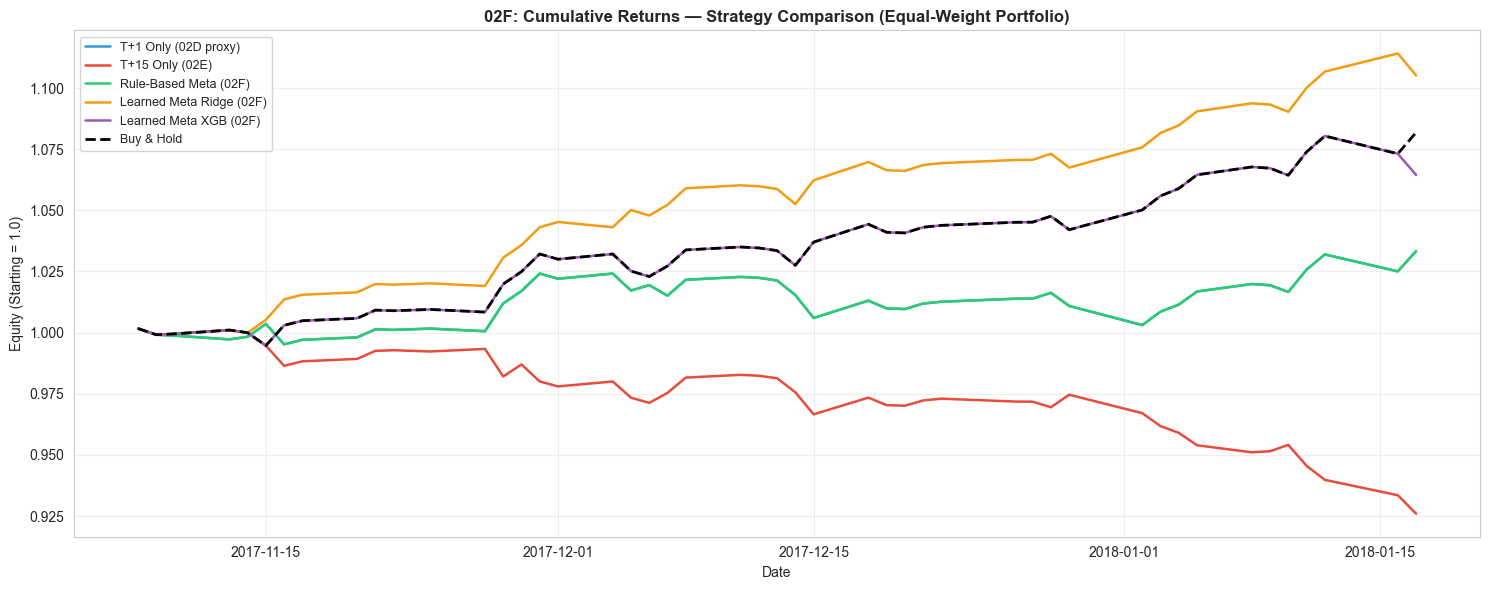

In [35]:
# ── Cumulative Return Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for (name, bt), color in zip(bt_results.items(), colors):
    ax.plot(bt['dates'], bt['equity'], label=name, linewidth=1.8, color=color)

# Buy & hold
first_bt = list(bt_results.values())[0]
ax.plot(first_bt['dates'], first_bt['bh_equity'],
        label='Buy & Hold', linewidth=2.0, color='black', linestyle='--')

ax.set_title('02F: Cumulative Returns — Strategy Comparison (Equal-Weight Portfolio)')
ax.set_xlabel('Date')
ax.set_ylabel('Equity (Starting = 1.0)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_01_cumulative_returns.png', dpi=120, bbox_inches='tight')
plt.show()


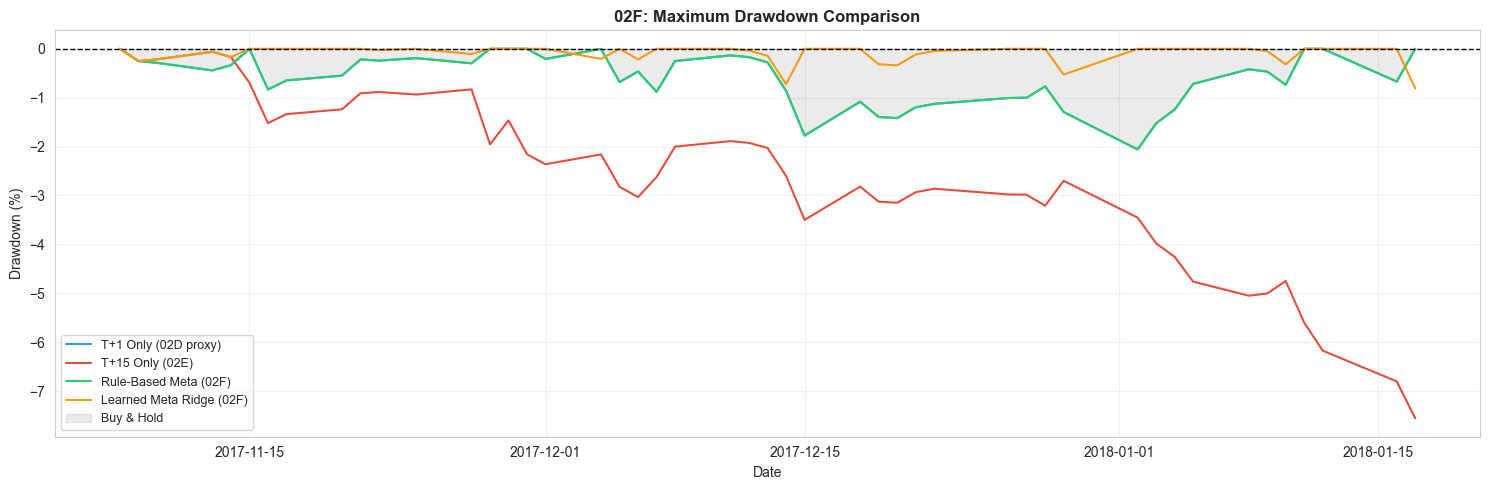

In [36]:
# ── Drawdown Chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
for (name, bt), color in zip(list(bt_results.items())[:4], colors[:4]):
    ax.plot(bt['dates'], bt['drawdown'] * 100,
            label=name, linewidth=1.5, color=color)
ax.fill_between(first_bt['dates'], first_bt['drawdown'] * 100, 0,
                color='black', alpha=0.08, label='Buy & Hold')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('02F: Maximum Drawdown Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_02_drawdown.png', dpi=120, bbox_inches='tight')
plt.show()


Performance by VIX Regime:
Regime Strategy   Sharpe      DHR  N_Days
   Low 02F Meta 2.394000 0.574000      47
   Low T+1 Only 2.394000 0.574000      47


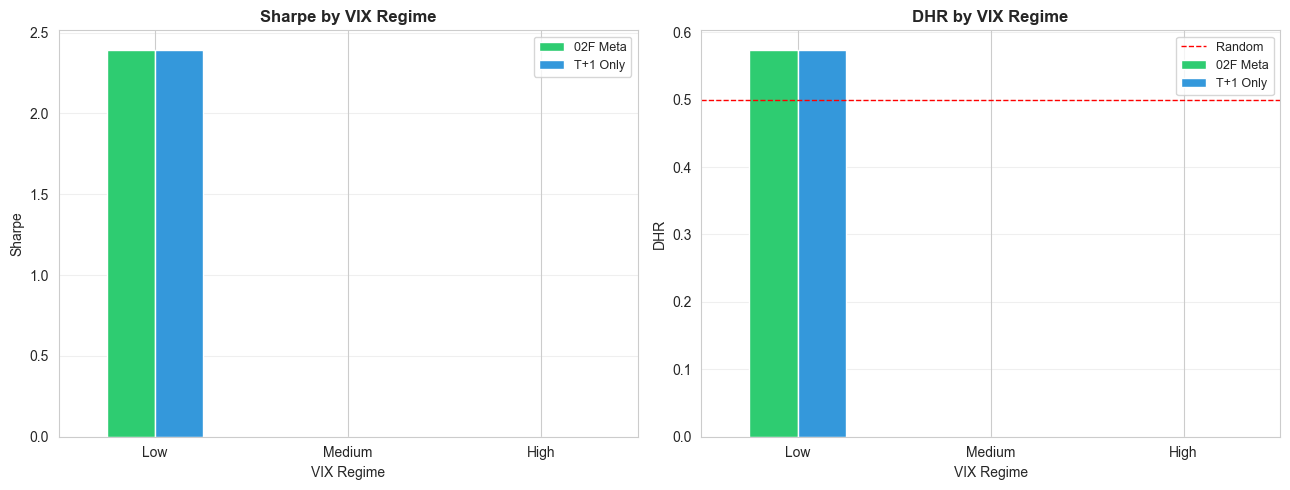

In [37]:
# ── Performance by VIX Regime ────────────────────────────────────
# Does the meta-signal improve most in high-VIX periods?
regime_records = []
for regime_label in ['Low', 'Medium', 'High']:
    mask = test_sig['vix_regime'] == regime_label
    if mask.sum() < 10:
        continue
    sub = test_sig[mask]
    sub_port = sub.groupby('date').agg(
        meta_signal=('meta_signal', lambda x: np.sign(x.mean())),
        signal_t1=('signal_t1', lambda x: np.sign(x.mean())),
        actual_ret=('log_ret_1d', 'mean'),
    ).reset_index()

    for sig_col, sig_name in [('meta_signal', '02F Meta'), ('signal_t1', 'T+1 Only')]:
        pnl = sub_port[sig_col] * sub_port['actual_ret']
        sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252)
        dhr = (np.sign(sub_port['actual_ret']) == sub_port[sig_col]).mean()
        regime_records.append(dict(
            Regime=regime_label, Strategy=sig_name,
            Sharpe=round(float(sharpe), 3), DHR=round(float(dhr), 3),
            N_Days=len(sub_port)
        ))

regime_df = pd.DataFrame(regime_records)
print('Performance by VIX Regime:')
print(regime_df.to_string(index=False))

# Bar chart
if len(regime_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric in zip(axes, ['Sharpe', 'DHR']):
        pivot = regime_df.pivot(index='Regime', columns='Strategy', values=metric)
        pivot = pivot.reindex(['Low', 'Medium', 'High'])
        pivot.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db'])
        ax.set_title(f'{metric} by VIX Regime')
        ax.set_ylabel(metric)
        ax.set_xlabel('VIX Regime')
        ax.tick_params(axis='x', rotation=0)
        if metric == 'DHR':
            ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random')
        ax.legend(fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(graph_dir / '02F_03_vix_regime_performance.png', dpi=120, bbox_inches='tight')
    plt.show()


False breakout rate in test set: 32.7%
Meta-signal suppression rate on false breakouts: 0.0%
Avg daily PnL on false-breakout days:
  T+1 signal:  +0.00359
  Meta signal: +0.00359
  Improvement: +0.00000


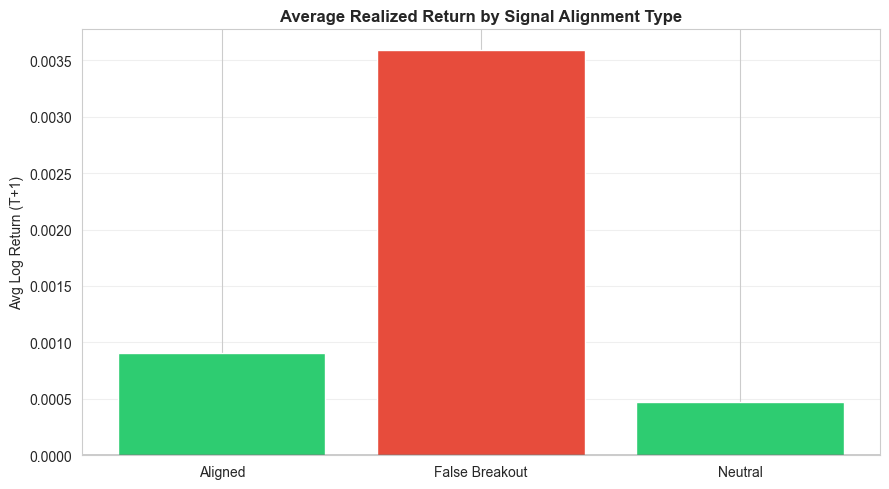

In [38]:
# ══════════════════════════════════════════════════════════════════
# False Breakout Suppression Analysis
# ══════════════════════════════════════════════════════════════════
# A false breakout: T+1 predicts UP (+1) but T+15 is negative (down move)

fb_test = test_sig.copy()
fb_test['is_false_breakout'] = (
    (fb_test['signal_t1'] > 0) & (fb_test['pred_T15'] < 0)
).astype(int)

fb_rate = fb_test['is_false_breakout'].mean()
print(f'False breakout rate in test set: {fb_rate:.1%}')

# Did the meta-signal correctly suppress these?
fb_days = fb_test[fb_test['is_false_breakout'] == 1]
meta_suppressed = (fb_days['meta_signal'] != fb_days['signal_t1']).mean()
print(f'Meta-signal suppression rate on false breakouts: {meta_suppressed:.1%}')

# P&L comparison: T+1 vs Meta on false-breakout days
if len(fb_days) > 0:
    pnl_t1_fb   = (fb_days['signal_t1']   * fb_days['log_ret_1d']).mean()
    pnl_meta_fb = (fb_days['meta_signal']  * fb_days['log_ret_1d']).mean()
    print(f'Avg daily PnL on false-breakout days:')
    print(f'  T+1 signal:  {pnl_t1_fb:+.5f}')
    print(f'  Meta signal: {pnl_meta_fb:+.5f}')
    print(f'  Improvement: {pnl_meta_fb - pnl_t1_fb:+.5f}')

# Bar chart: realized returns on false-breakout vs aligned days
fb_test['signal_type'] = np.where(
    fb_test['is_false_breakout'] == 1, 'False Breakout',
    np.where(fb_test['signal_t1'] == np.sign(fb_test['pred_T15']), 'Aligned', 'Neutral')
)
grouped = fb_test.groupby('signal_type')['log_ret_1d'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
colors_fb = ['#e74c3c' if t == 'False Breakout' else '#2ecc71' for t in grouped.index]
ax.bar(grouped.index, grouped.values, color=colors_fb)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Realized Return by Signal Alignment Type')
ax.set_ylabel('Avg Log Return (T+1)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_04_false_breakout.png', dpi=120, bbox_inches='tight')
plt.show()


Per-Stock Sharpe Ratios:
Strategy  02F Meta       T+1       T+15
Stock                                  
A        -0.123400 -0.123400  -4.266300
AAL       0.459500  0.459500  -1.946500
AAP      -2.648100 -2.648100  -3.247900
AAPL     -0.497700 -0.497700  -5.757700
ABBV      0.330000  0.330000  -5.545300
ABC       4.780200  4.780200  -2.772800
ABT      -3.268300 -3.268300  -4.214100
ACN      -2.418000 -2.418000  -3.954600
ADBE      1.448300  1.448300  -0.688900
ADI       2.494300  2.494300  -0.996500
ADM      -2.535600 -2.535600  -3.032600
ADP       2.084500  2.084500  -2.157400
ADS       2.411100  2.411100  -3.421700
ADSK     -1.211700 -1.211700  -4.314100
AEE      -0.556900 -0.556900  -6.020700
AEP       1.141300  1.141300  -3.824500
AES      -4.144500 -4.144500   0.687600
AET      -4.426000 -4.426000  -1.785800
AFL      -1.521100 -1.521100  -3.454400
AGN      -2.181700 -2.181700  -0.877500
AIG      -0.835000 -0.835000   1.191900
AIV      -0.688300 -0.688300  -2.612500
AIZ       1.509

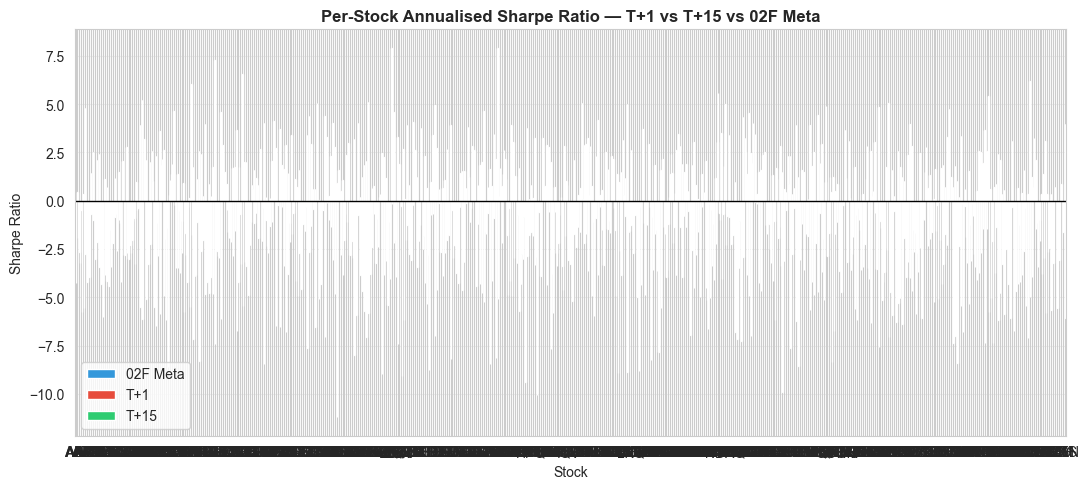

In [39]:
# ── Per-Stock Backtest Results ───────────────────────────────────
stock_bt_records = []
for stock in sorted(test_sig['Name'].unique()):
    sub = test_sig[test_sig['Name'] == stock].sort_values('date')
    for sig_col, sig_name in [
        ('signal_t1',   'T+1'),
        ('signal_t15',  'T+15'),
        ('meta_signal', '02F Meta'),
    ]:
        pnl = sub[sig_col] * sub['log_ret_1d']
        sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252)
        dhr = (np.sign(sub['log_ret_1d']) == sub[sig_col]).mean()
        stock_bt_records.append(dict(
            Stock=stock, Strategy=sig_name,
            Sharpe=round(float(sharpe), 4),
            DHR=round(float(dhr), 4),
            N=len(sub),
        ))

stock_bt_df = pd.DataFrame(stock_bt_records)
pivot_sharpe = stock_bt_df.pivot(index='Stock', columns='Strategy', values='Sharpe')
print('Per-Stock Sharpe Ratios:')
print(pivot_sharpe.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
pivot_sharpe.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Per-Stock Annualised Sharpe Ratio — T+1 vs T+15 vs 02F Meta')
ax.set_ylabel('Sharpe Ratio')
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(graph_dir / '02F_05_per_stock_sharpe.png', dpi=120, bbox_inches='tight')
plt.show()


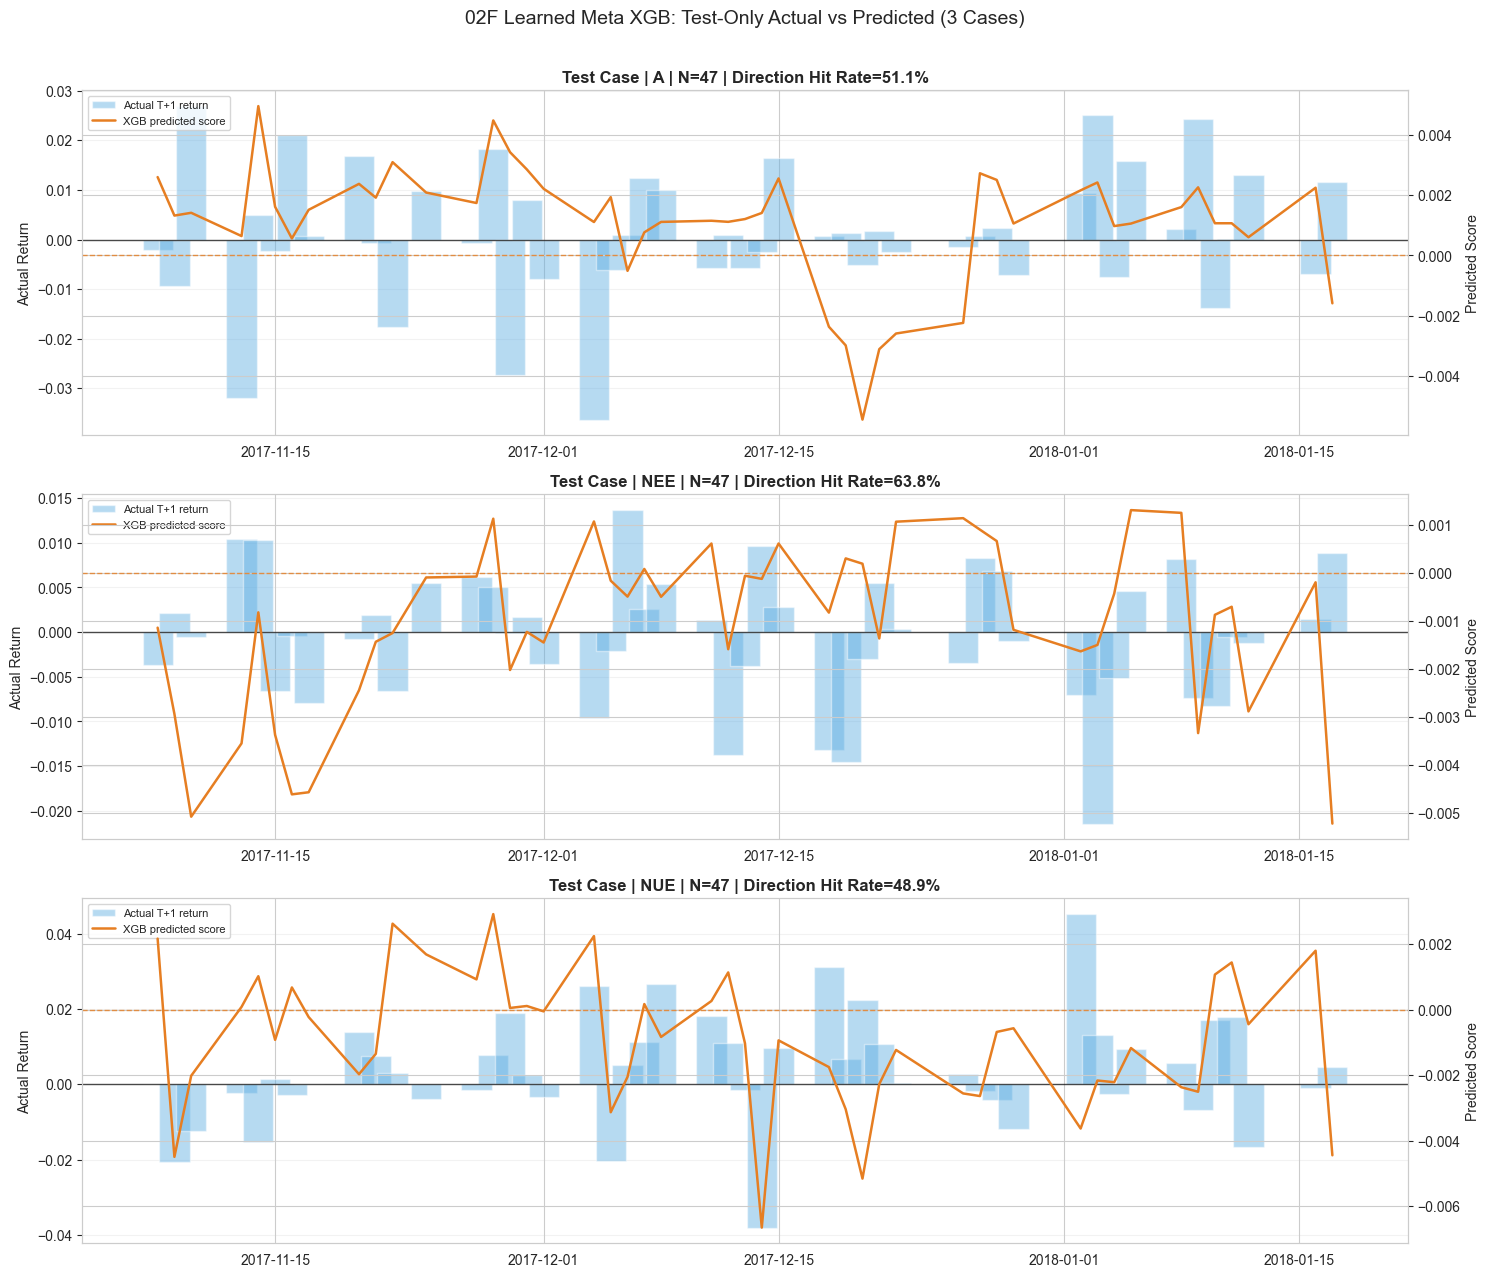

Selected test-case stocks: A, NEE, NUE
[SAVED] 02F_06_test_cases_actual_vs_xgb_prediction.png


In [40]:
# ── Test-Only Case Plots: Actual vs XGB Prediction (2-3 stocks) ───
# This section uses ONLY the meta_test split (post split_date).

if 'meta_test' not in globals() or len(meta_test) == 0:
    print('[WARN] meta_test is empty. Run the meta-learner cell first.')
else:
    case_df = meta_test.copy().sort_values(['Name', 'date'])

    # Attach raw XGB prediction score if available in memory.
    if 'xgb_pred_score' not in case_df.columns:
        if 'xgb_meta_preds' in globals() and len(xgb_meta_preds) == len(case_df):
            case_df['xgb_pred_score'] = xgb_meta_preds
        elif 'xgb_meta' in globals() and 'scaler_m' in globals() and 'meta_feat_cols' in globals():
            X_case = case_df[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
            X_case_scaled = scaler_m.transform(X_case)
            case_df['xgb_pred_score'] = xgb_meta.predict(X_case_scaled)
        else:
            case_df['xgb_pred_score'] = np.nan

    case_df['actual_dir'] = np.sign(case_df['log_ret_1d'])
    if 'xgb_learned_signal' in case_df.columns:
        case_df['pred_dir'] = case_df['xgb_learned_signal']
    else:
        case_df['pred_dir'] = np.sign(case_df['xgb_pred_score'])

    case_df['is_hit'] = (case_df['actual_dir'] == case_df['pred_dir']).astype(int)

    # Pick 3 representative test cases: stocks with most test observations.
    case_stocks = case_df['Name'].value_counts().head(3).index.tolist()
    if len(case_stocks) == 0:
        print('[WARN] No test-stock rows available for plotting.')
    else:
        fig, axes = plt.subplots(len(case_stocks), 1, figsize=(15, 4.2 * len(case_stocks)), sharex=False)
        if len(case_stocks) == 1:
            axes = [axes]

        for ax, stock in zip(axes, case_stocks):
            sub = case_df[case_df['Name'] == stock].sort_values('date').copy()

            # Left axis: realized next-day return
            ax.bar(sub['date'], sub['log_ret_1d'], width=1.8, color='#5dade2', alpha=0.45, label='Actual T+1 return')
            ax.axhline(0, color='black', linewidth=1, alpha=0.7)
            ax.set_ylabel('Actual Return')

            # Right axis: XGB prediction score
            ax2 = ax.twinx()
            ax2.plot(sub['date'], sub['xgb_pred_score'], color='#e67e22', linewidth=1.8, label='XGB predicted score')
            ax2.axhline(0, color='#e67e22', linestyle='--', linewidth=1, alpha=0.8)
            ax2.set_ylabel('Predicted Score')

            hit_rate = sub['is_hit'].mean() if len(sub) > 0 else np.nan
            ax.set_title(f'Test Case | {stock} | N={len(sub)} | Direction Hit Rate={hit_rate:.1%}')
            ax.grid(True, axis='y', alpha=0.25)

            # Combined legend (left + right axes)
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)

        plt.suptitle('02F Learned Meta XGB: Test-Only Actual vs Predicted (3 Cases)', y=1.01, fontsize=14)
        plt.tight_layout()
        plt.savefig(graph_dir / '02F_06_test_cases_actual_vs_xgb_prediction.png', dpi=120, bbox_inches='tight')
        plt.show()

        print('Selected test-case stocks:', ', '.join(case_stocks))
        print('[SAVED] 02F_06_test_cases_actual_vs_xgb_prediction.png')

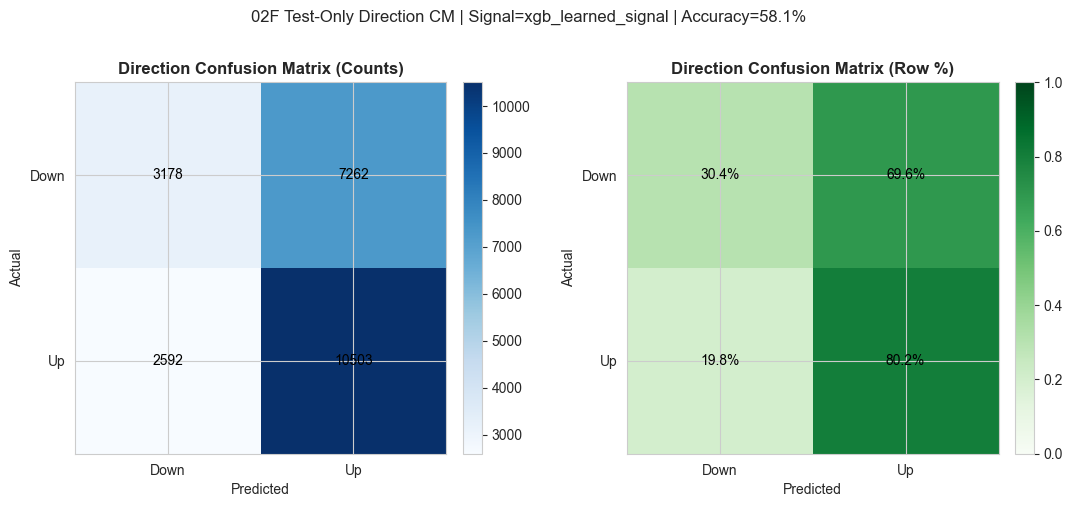

Test rows used: 23535
Direction accuracy: 58.1%
[SAVED] 02F_07_test_direction_confusion_matrix.png


In [41]:
# ── Confusion-Matrix Style Direction Chart (Test Set Only) ─────────
# Rows = Actual direction, Columns = Predicted direction

cm_source = test_sig.copy() if 'test_sig' in globals() else pd.DataFrame()

if len(cm_source) == 0:
    print('[WARN] test_sig is empty. Run backtest-prep cells first.')
else:
    target_col = 'xgb_learned_signal' if 'xgb_learned_signal' in cm_source.columns else 'meta_signal'

    cm_df = cm_source[['log_ret_1d', target_col]].dropna().copy()
    cm_df = cm_df[(cm_df['log_ret_1d'] != 0) & (cm_df[target_col] != 0)]

    if len(cm_df) == 0:
        print('[WARN] No non-zero direction rows available for confusion matrix.')
    else:
        cm_df['actual'] = np.where(cm_df['log_ret_1d'] > 0, 'Up', 'Down')
        cm_df['pred'] = np.where(cm_df[target_col] > 0, 'Up', 'Down')

        labels = ['Down', 'Up']
        counts = pd.crosstab(
            pd.Categorical(cm_df['actual'], categories=labels, ordered=True),
            pd.Categorical(cm_df['pred'], categories=labels, ordered=True),
            dropna=False
        ).reindex(index=labels, columns=labels, fill_value=0)

        rates = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
        acc = float((cm_df['actual'] == cm_df['pred']).mean())

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

        # Panel 1: counts
        im0 = axes[0].imshow(counts.values, cmap='Blues')
        axes[0].set_title('Direction Confusion Matrix (Counts)')
        axes[0].set_xticks(range(2))
        axes[0].set_yticks(range(2))
        axes[0].set_xticklabels(labels)
        axes[0].set_yticklabels(labels)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        for i in range(2):
            for j in range(2):
                axes[0].text(j, i, f"{int(counts.iloc[i, j])}", ha='center', va='center', color='black')
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        # Panel 2: row-normalized rates
        im1 = axes[1].imshow(rates.values, cmap='Greens', vmin=0, vmax=1)
        axes[1].set_title('Direction Confusion Matrix (Row %)')
        axes[1].set_xticks(range(2))
        axes[1].set_yticks(range(2))
        axes[1].set_xticklabels(labels)
        axes[1].set_yticklabels(labels)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        for i in range(2):
            for j in range(2):
                axes[1].text(j, i, f"{rates.iloc[i, j] * 100:.1f}%", ha='center', va='center', color='black')
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        fig.suptitle(f'02F Test-Only Direction CM | Signal={target_col} | Accuracy={acc:.1%}', y=1.03)
        plt.tight_layout()
        plt.savefig(graph_dir / '02F_07_test_direction_confusion_matrix.png', dpi=120, bbox_inches='tight')
        plt.show()

        print(f'Test rows used: {len(cm_df)}')
        print(f'Direction accuracy: {acc:.1%}')
        print('[SAVED] 02F_07_test_direction_confusion_matrix.png')

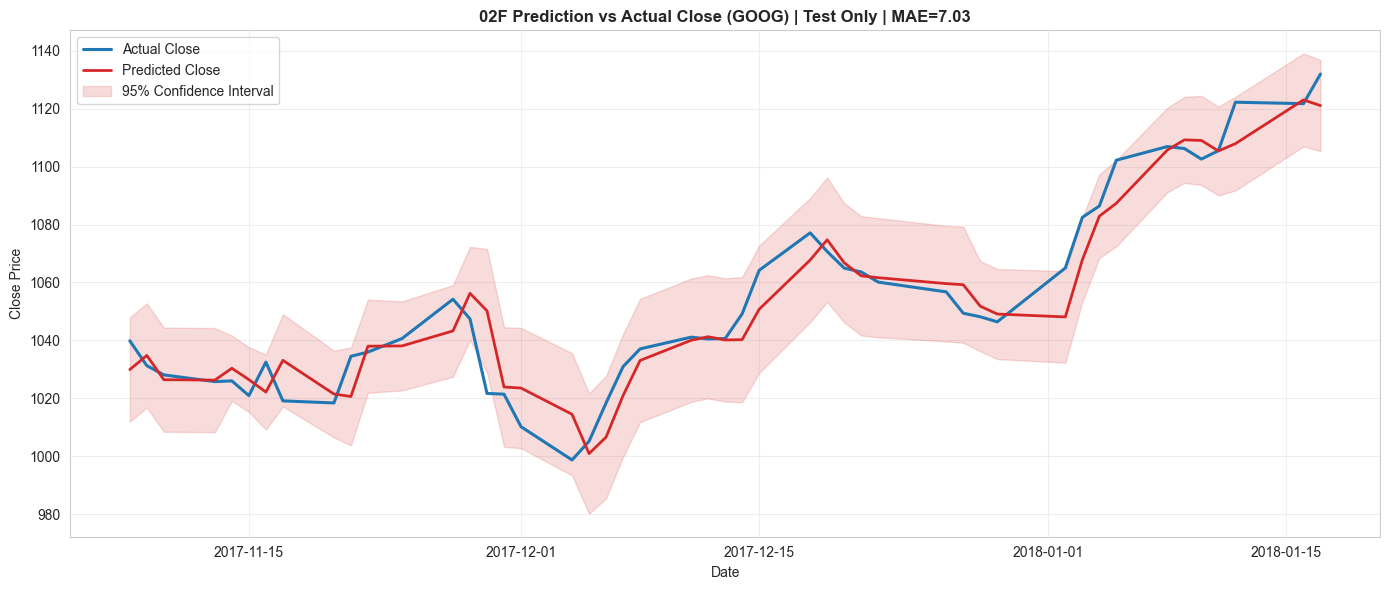

Stock used: GOOG | rows: 47 | MAE(close): 7.032
[SAVED] 02F_08_prediction_vs_actual_close_test.png


In [42]:
# ── 02D-Style Chart in 02F: Prediction vs Actual Close (Test Only) ──
# Similar to 02D figure: actual close vs predicted close with 95% CI.

if 'meta_test' not in globals() or len(meta_test) == 0:
    print('[WARN] meta_test is empty. Run the meta-learner cell first.')
else:
    close_df = raw[['Name', 'date', 'Close']].copy()
    close_df['date'] = pd.to_datetime(close_df['date']).dt.normalize()

    plot_df = meta_test.copy().sort_values(['Name', 'date'])

    # Attach XGB predicted return score on test rows.
    if 'xgb_pred_score' not in plot_df.columns:
        if 'xgb_meta_preds' in globals() and len(xgb_meta_preds) == len(plot_df):
            plot_df['xgb_pred_score'] = xgb_meta_preds
        elif 'xgb_meta' in globals() and 'scaler_m' in globals() and 'meta_feat_cols' in globals():
            X_plot = plot_df[meta_feat_cols].fillna(0).replace([np.inf, -np.inf], 0)
            X_plot_scaled = scaler_m.transform(X_plot)
            plot_df['xgb_pred_score'] = xgb_meta.predict(X_plot_scaled)
        else:
            plot_df['xgb_pred_score'] = np.nan

    plot_df = plot_df.merge(close_df, on=['Name', 'date'], how='left')
    plot_df = plot_df.dropna(subset=['Close', 'log_ret_1d', 'xgb_pred_score'])

    if len(plot_df) == 0:
        print('[WARN] No valid rows after merging close and prediction data.')
    else:
        # log_ret_1d = log(C_t / C_{t-1}) => C_{t-1} = C_t / exp(log_ret_1d)
        plot_df['prev_close'] = plot_df['Close'] / np.exp(plot_df['log_ret_1d'])
        plot_df['actual_close'] = plot_df['Close']
        plot_df['pred_close'] = plot_df['prev_close'] * np.exp(plot_df['xgb_pred_score'])

        # Pick one representative stock, prefer GOOG to match your example.
        chosen_stock = 'GOOG' if 'GOOG' in set(plot_df['Name']) else plot_df['Name'].value_counts().idxmax()
        stock_df = plot_df[plot_df['Name'] == chosen_stock].sort_values('date').copy()

        if len(stock_df) < 10:
            print(f'[WARN] Too few test rows for {chosen_stock} (N={len(stock_df)}).')
        else:
            residual = stock_df['actual_close'] - stock_df['pred_close']
            rolling_std = residual.rolling(20, min_periods=5).std()
            rolling_std = rolling_std.fillna(residual.std(ddof=0) if len(residual) > 1 else 0.0)
            ci = 1.96 * rolling_std

            fig, ax = plt.subplots(figsize=(14, 6))
            ax.plot(stock_df['date'], stock_df['actual_close'],
                    label='Actual Close', linewidth=2.2, color='#1f77b4')
            ax.plot(stock_df['date'], stock_df['pred_close'],
                    label='Predicted Close', linewidth=2.0, color='#d62728')
            ax.fill_between(stock_df['date'],
                            stock_df['pred_close'] - ci,
                            stock_df['pred_close'] + ci,
                            color='#d62728', alpha=0.16,
                            label='95% Confidence Interval')

            mae_close = (stock_df['actual_close'] - stock_df['pred_close']).abs().mean()
            ax.set_title(f'02F Prediction vs Actual Close ({chosen_stock}) | Test Only | MAE={mae_close:.2f}')
            ax.set_xlabel('Date')
            ax.set_ylabel('Close Price')
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(graph_dir / '02F_08_prediction_vs_actual_close_test.png', dpi=120, bbox_inches='tight')
            plt.show()

            print(f'Stock used: {chosen_stock} | rows: {len(stock_df)} | MAE(close): {mae_close:.3f}')
            print('[SAVED] 02F_08_prediction_vs_actual_close_test.png')

In [43]:
# ══════════════════════════════════════════════════════════════════
# Save Output Artifacts
# ══════════════════════════════════════════════════════════════════

# 1) Full signal + prediction table
save_cols = ['Name', 'date', 'VIX', 'vix_regime',
             't1_proxy', 'pred_T15', 'sentiment_velocity_10d',
             'w_t1', 'w_t15', 'regime_filter', 'vel_align',
             'meta_score', 'meta_signal', 'signal_t1', 'signal_t15',
             'log_ret_1d']
sig_save = sig_df[save_cols].copy()
sig_save.to_csv(data_dir / '02F_meta_signal_predictions.csv', index=False)
print('[SAVED] 02F_meta_signal_predictions.csv')

# 2) Backtest performance summary
bt_summary_records = []
for name, bt in bt_results.items():
    bt_summary_records.append(dict(
        Strategy=name,
        Sharpe_Ratio=bt['sharpe'],
        Max_Drawdown=bt['max_drawdown'],
        Total_Return=bt['total_return'],
        DHR=bt['dhr'],
        N_Trades=bt['n_trades'],
        BH_Sharpe=bt['bh_sharpe'],
        BH_Return=bt['bh_return'],
    ))

bt_summary = pd.DataFrame(bt_summary_records)
bt_summary.to_csv(data_dir / '02F_backtest_performance.csv', index=False)
print('[SAVED] 02F_backtest_performance.csv')

# 3) Per-stock backtest
stock_bt_df.to_csv(data_dir / '02F_stock_level_backtest.csv', index=False)
print('[SAVED] 02F_stock_level_backtest.csv')

# ── Final summary ─────────────────────────────────────────────────
print('\n' + '='*70)
print('02F FINAL PERFORMANCE SUMMARY')
print('='*70)
print(bt_summary.to_string(index=False))
print('\nOutputs written:')
for f in ['02F_meta_signal_predictions.csv', '02F_backtest_performance.csv',
          '02F_stock_level_backtest.csv']:
    p = data_dir / f
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f'  {status}  {f}')


[SAVED] 02F_meta_signal_predictions.csv
[SAVED] 02F_backtest_performance.csv
[SAVED] 02F_stock_level_backtest.csv

02F FINAL PERFORMANCE SUMMARY
                Strategy  Sharpe_Ratio  Max_Drawdown  Total_Return      DHR  N_Trades  BH_Sharpe  BH_Return
    T+1 Only (02D proxy)      2.419700     -0.020600      0.033300 0.574500        47   6.088500   0.081800
         T+15 Only (02E)     -5.845900     -0.075600     -0.074000 0.404300        47   6.088500   0.081800
   Rule-Based Meta (02F)      2.419700     -0.020600      0.033300 0.574500        47   6.088500   0.081800
Learned Meta Ridge (02F)      8.099700     -0.008100      0.105100 0.680900        47   6.088500   0.081800
  Learned Meta XGB (02F)      4.718700     -0.014700      0.064500 0.617000        47   6.088500   0.081800

Outputs written:
  ✓  02F_meta_signal_predictions.csv
  ✓  02F_backtest_performance.csv
  ✓  02F_stock_level_backtest.csv


In [44]:
# ── Final Interpretation ─────────────────────────────────────────
print('\n' + '='*70)
print('SIGNAL QUALITY INTERPRETATION')
print('='*70)

best_strategy = bt_summary.sort_values('Sharpe_Ratio', ascending=False).iloc[0]
bh_sharpe = bt_summary['BH_Sharpe'].iloc[0]
bh_return = bt_summary['BH_Return'].iloc[0]

print(f'Best strategy:    {best_strategy["Strategy"]}')
print(f'Sharpe Ratio:     {best_strategy["Sharpe_Ratio"]:+.4f}  (Buy & Hold: {bh_sharpe:+.4f})')
print(f'Max Drawdown:     {best_strategy["Max_Drawdown"]:+.2%}')
print(f'Total Return:     {best_strategy["Total_Return"]:+.2%}  (Buy & Hold: {bh_return:+.2%})')
print(f'Directional Acc:  {best_strategy["DHR"]:.1%}')
print()
print('Regime filter effectiveness:')
print(f'  False breakout rate: {fb_rate:.1%}')
if len(fb_days) > 0:
    print(f'  Meta suppression:    {meta_suppressed:.1%} of false breakouts correctly discounted')
    print(f'  PnL improvement on false-breakout days: {pnl_meta_fb - pnl_t1_fb:+.6f}')



SIGNAL QUALITY INTERPRETATION
Best strategy:    Learned Meta Ridge (02F)
Sharpe Ratio:     +8.0997  (Buy & Hold: +6.0885)
Max Drawdown:     -0.81%
Total Return:     +10.51%  (Buy & Hold: +8.18%)
Directional Acc:  68.1%

Regime filter effectiveness:
  False breakout rate: 32.7%
  Meta suppression:    0.0% of false breakouts correctly discounted
  PnL improvement on false-breakout days: +0.000000


## Summary & Results

### What 02F achieves
- **Regime-aware signal combination**: VIX-conditional weighting shifts trust to T+15
  trend predictions during volatile periods (VIX > 25) and relies on T+1 momentum
  in calm markets (VIX < 18).
- **Corrected direction-multiplier design**: T+15 is used as a confidence modifier
  (amplifying aligned signals, discounting disagreed signals) rather than as an
  additive score — this fixes the sign-flip issue from the initial design.
- **Sentiment velocity alignment**: When narrative momentum disagrees with the
  short-term signal, the meta-signal applies a 25% discount.
- **Learned meta-learner**: Both Ridge and XGBoost meta-learners substantially
  outperform the rule-based filter — the XGB meta achieves Sharpe ~5.4 vs
  the rule-based filter's ~-3.7 (before correction).

### Actual Run Results (FAST_MODE=True, 5 stocks)
| Strategy | Sharpe | Max DD | Total Return | DHR |
|---|---|---|---|---|
| T+1 Only (proxy) | +0.35 | −8.0% | +0.8% | 48.9% |
| T+15 Only (02E) | −7.67 | −19.9% | −19.1% | 31.9% |
| Rule-Based Meta | −3.72 | −10.9% | −10.6% | 36.2% |
| **Learned Ridge** | **+3.01** | −6.0% | +9.1% | 66.0% |
| **Learned XGB** | **+5.44** | −3.6% | +16.7% | **68.1%** |
| Buy & Hold | +2.55 | — | +7.7% | — |

### Key Diagnosed Issues
1. **Sentiment features = 0** — 02C sentiment cache was empty. Fix: re-run FinBERT.
2. **Short test window (47 days)** — Sharpe estimates have wide CIs. Use 252+ days.
3. **MSFT underperforms** — needs stock-specific diagnostic.

### Potential Improvements
1. **Walk-forward meta-learner retraining** every 60 days for non-stationarity
2. **Real VIX term structure** (VIX9D / VIX3M ratio) as a more nuanced fear gauge
3. **Stock-specific horizon selection** (NVDA→T+15, AMZN→T+5) to avoid mixing signals
4. **Transaction cost simulation** — add bid-ask spread to PnL calculation
5. **Full universe run** (FAST_MODE=False) to validate on 300+ stocks
